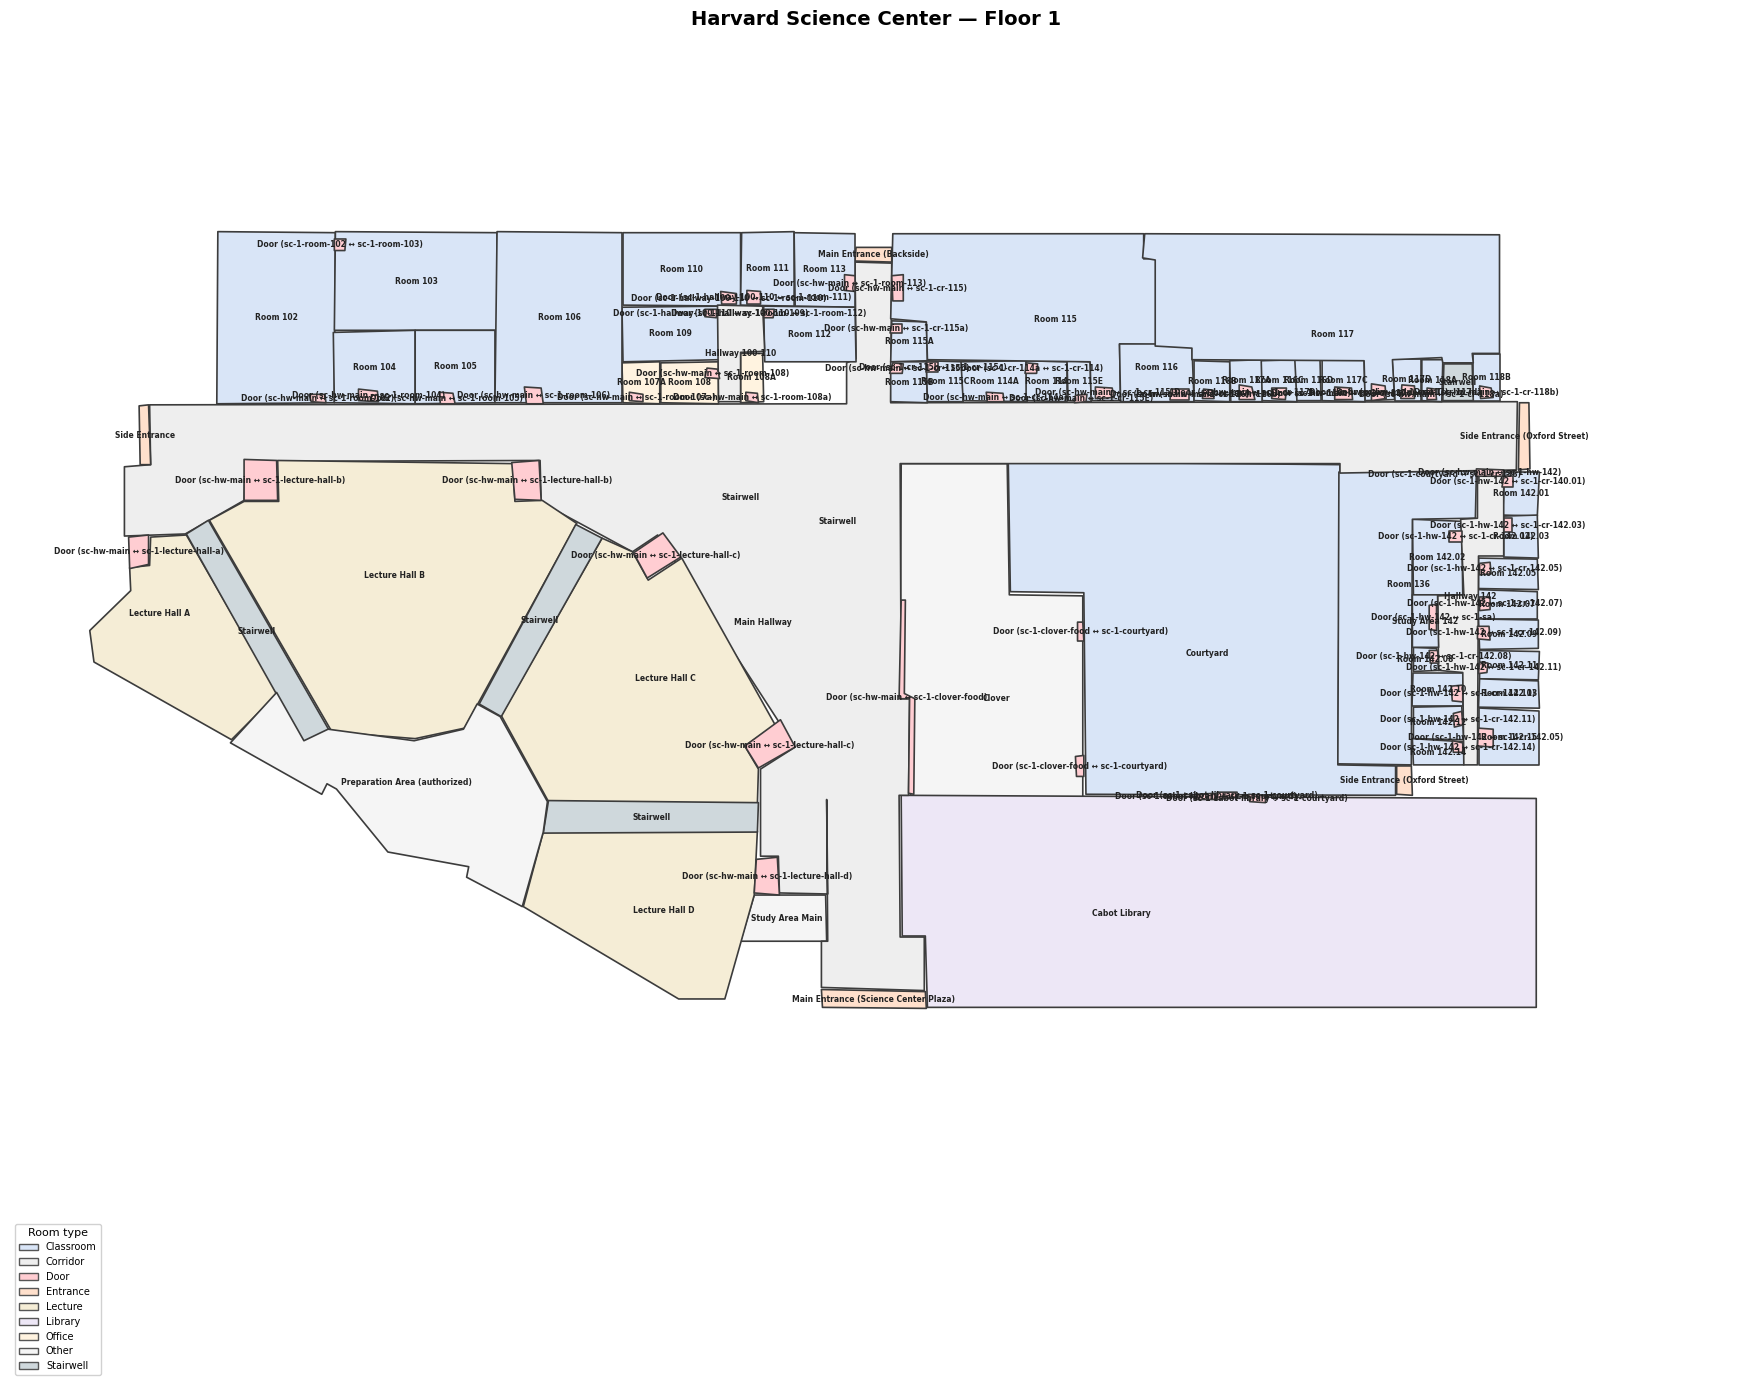


Loaded 125 rooms.


In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np

with open('Floor Plans/floor1.json') as f:
    floor1 = json.load(f)

TYPE_COLORS = {
    'classroom':  '#D9E5F7',
    'lecture':    '#F5EDD6',
    'lobby':      '#FDF6E3',
    'corridor':   '#EEEEEE',
    'connection': '#E0F7FA',
    'door':       '#FFCDD2',
    'entrance':   '#FFE0CC',
    'lab':        '#DAF0DE',
    'library':    '#EDE7F6',
    'stairwell':  '#CFD8DC',
    'elevator':   '#CFD8DC',
    'office':     '#FFF3E0',
    'other':      '#F5F5F5',
}

W = floor1['viewBox']['width']   # 1650
H = floor1['viewBox']['height']  # 1275

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor('#E8E0D0')
fig.patch.set_facecolor('#FFFFFF')

legend_done = set()
patches, colors = [], []

for room in floor1['rooms']:
    pts = np.array(room['polygon'])
    pts[:, 1] = H - pts[:, 1]   # flip Y so north is up

    color = TYPE_COLORS.get(room['type'], '#EEEEEE')
    poly = Polygon(pts, closed=True)
    patches.append(poly)
    colors.append(color)

    # Label
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()
    ax.text(cx, cy, room['name'], ha='center', va='center',
            fontsize=5.5, fontweight='bold', color='#222',
            wrap=True, zorder=4)

    if room['type'] not in legend_done:
        legend_done.add(room['type'])

col = PatchCollection(patches, facecolors=colors,
                      edgecolors='#3C3C3C', linewidths=1.2, zorder=2)
ax.add_collection(col)

legend_handles = [
    mpatches.Patch(facecolor=TYPE_COLORS.get(t, '#EEE'), edgecolor='#555',
                   label=t.capitalize())
    for t in sorted(legend_done)
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=7,
          framealpha=0.9, title='Room type', title_fontsize=8)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_title('Harvard Science Center — Floor 1', fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'\nLoaded {len(floor1["rooms"])} rooms.')

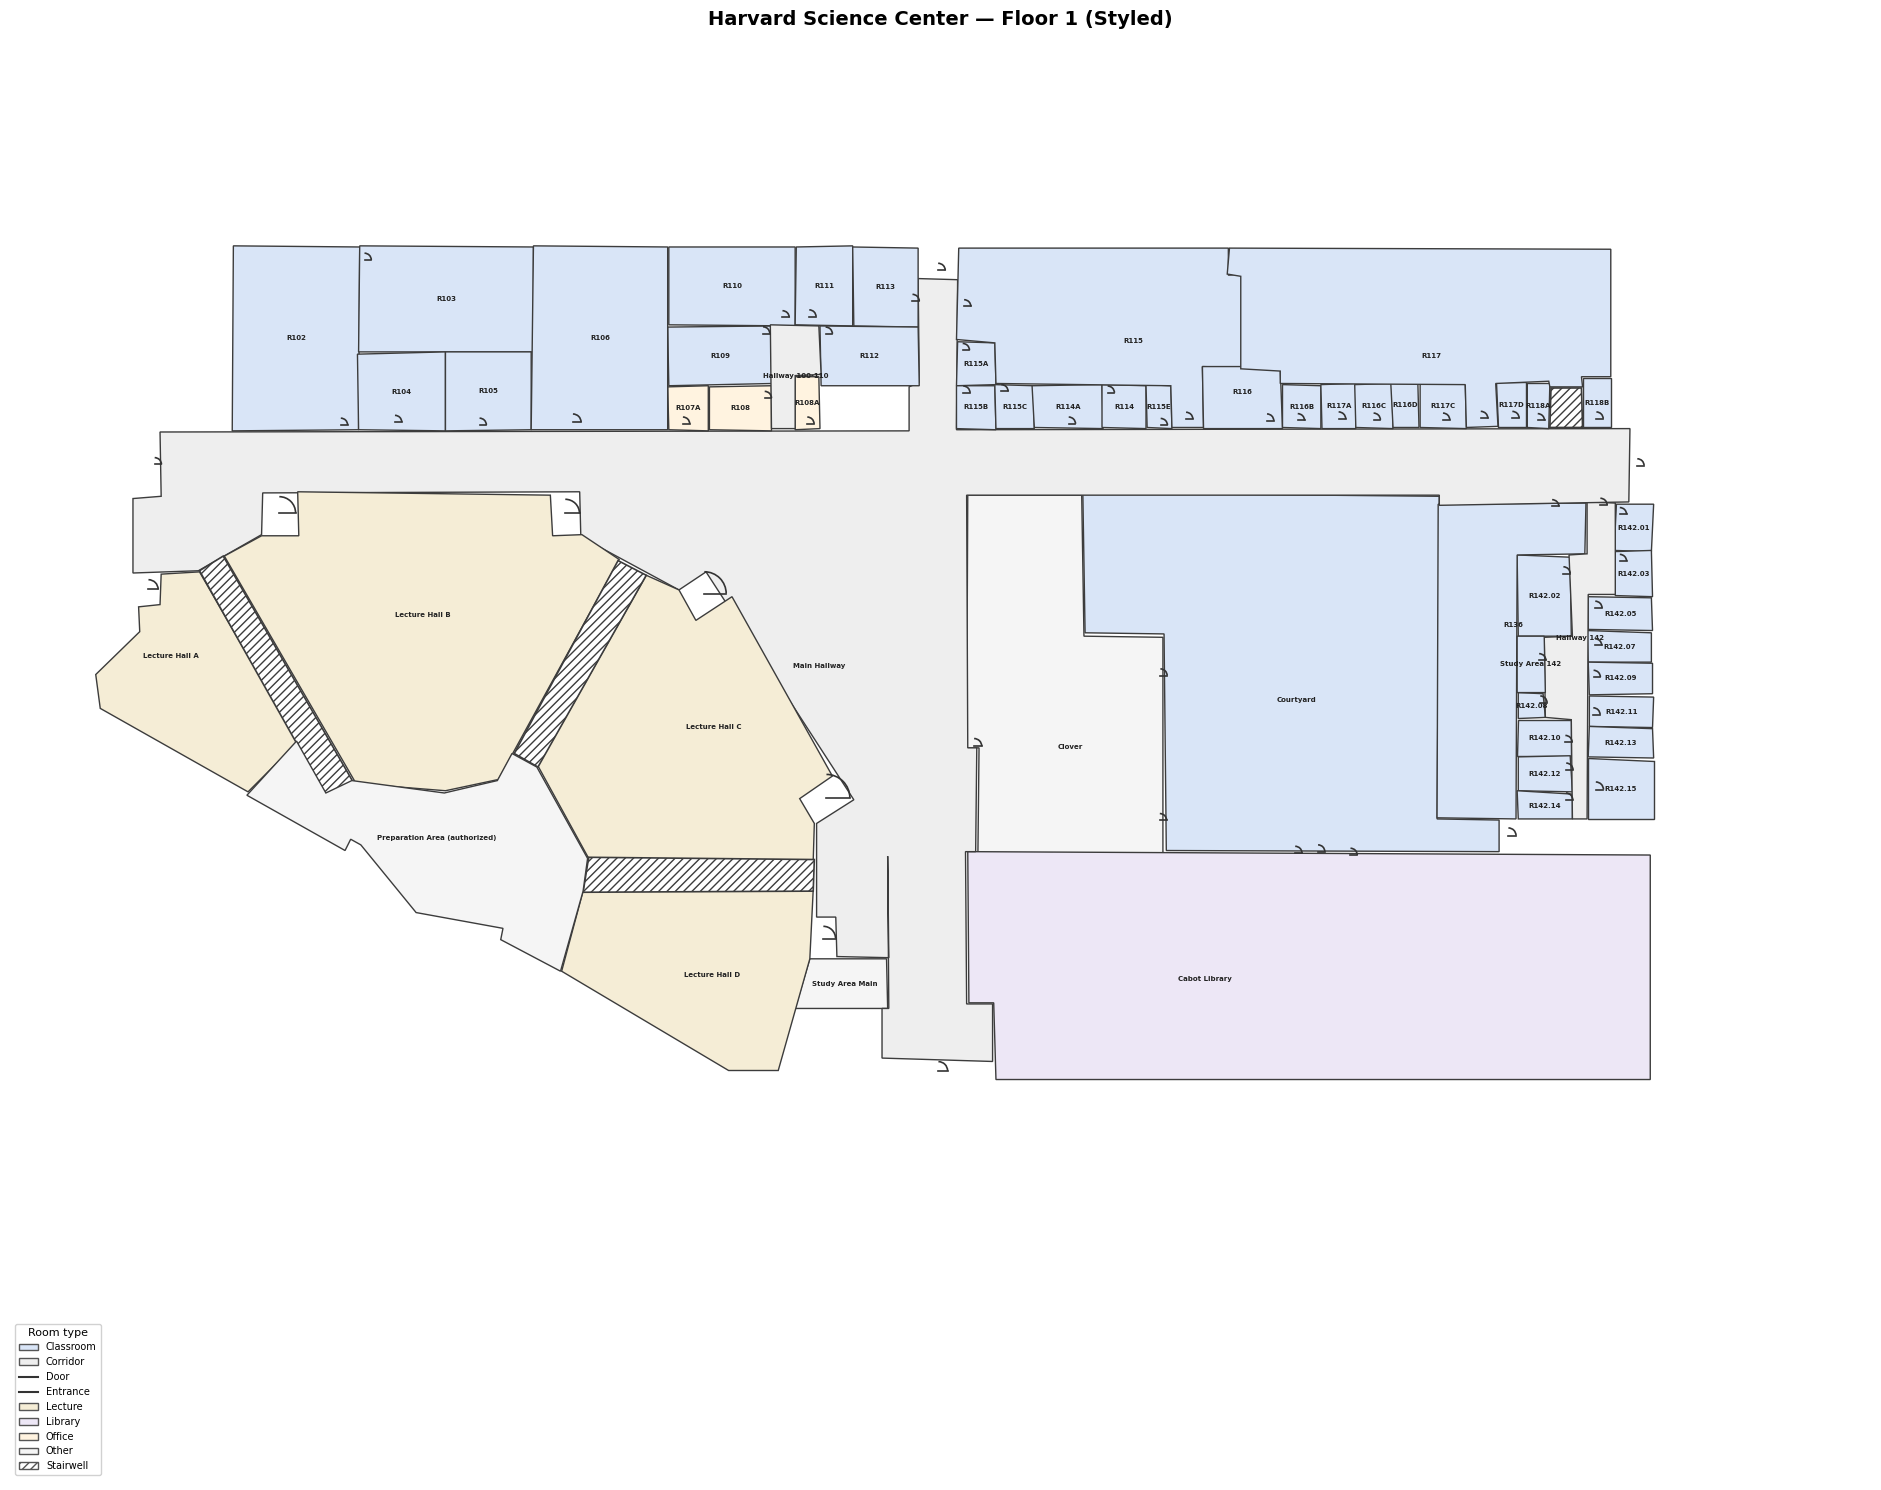

Rooms rendered: 125


In [ ]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon, Arc, FancyArrowPatch
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D

with open('Floor Plans/floor1_styled_improved.json') as f:
    floor1s = json.load(f)

TYPE_COLORS = {
    'classroom':  '#D9E5F7',
    'lecture':    '#F5EDD6',
    'lobby':      '#FDF6E3',
    'corridor':   '#EEEEEE',
    'connection': '#E0F7FA',
    'door':       '#FFFFFF',
    'entrance':   '#FFFFFF',
    'lab':        '#DAF0DE',
    'library':    '#EDE7F6',
    'stairwell':  '#FFFFFF',
    'elevator':   '#CFD8DC',
    'office':     '#FFF3E0',
    'other':      '#F5F5F5',
}

W = floor1s['viewBox']['width']
H = floor1s['viewBox']['height']

fig, ax = plt.subplots(figsize=(20, 15))
ax.set_facecolor('#E8E0D0')
fig.patch.set_facecolor('#FFFFFF')

legend_done = set()

for room in floor1s['rooms']:
    pts = np.array(room['polygon'], dtype=float)
    pts[:, 1] = H - pts[:, 1]
    sym = room.get('symbol', '')
    t   = room['type']
    color = room.get('color', TYPE_COLORS.get(t, '#EEEEEE'))
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()

    if sym == 'hatch_diagonal':
        # Stairwell: white fill + diagonal hatch, no label
        poly = Polygon(pts, closed=True,
                       facecolor='white', edgecolor='#3C3C3C',
                       hatch='////', linewidth=1.2, zorder=2)
        ax.add_patch(poly)

    elif sym == 'door_arc':
        # Door symbol: short line + quarter-circle arc
        r = min(
            max(pts[:, 0]) - min(pts[:, 0]),
            max(pts[:, 1]) - min(pts[:, 1])
        ) * 0.45
        r = max(r, 6)
        # Line (door panel)
        ax.plot([cx, cx + r], [cy, cy], color='#333', lw=1.2, zorder=5)
        # Arc (swing)
        arc = Arc((cx, cy), 2*r, 2*r, angle=0,
                  theta1=0, theta2=90,
                  color='#333', lw=1.2, zorder=5)
        ax.add_patch(arc)

    else:
        poly = Polygon(pts, closed=True,
                       facecolor=color, edgecolor='#3C3C3C',
                       linewidth=1.0, zorder=2)
        ax.add_patch(poly)
        if room['name']:
            ax.text(cx, cy, room['name'],
                    ha='center', va='center',
                    fontsize=5, fontweight='bold',
                    color='#222', zorder=4)

    if t not in legend_done:
        legend_done.add(t)

# Legend
legend_handles = []
for t in sorted(legend_done):
    if t == 'stairwell':
        legend_handles.append(
            mpatches.Patch(facecolor='white', edgecolor='#555',
                           hatch='////', label='Stairwell'))
    elif t in ('door', 'entrance', 'connection'):
        legend_handles.append(
            Line2D([0], [0], color='#333', lw=1.5, label=t.capitalize()))
    else:
        legend_handles.append(
            mpatches.Patch(facecolor=TYPE_COLORS.get(t, '#EEE'),
                           edgecolor='#555', label=t.capitalize()))

ax.legend(handles=legend_handles, loc='lower left',
          fontsize=7, framealpha=0.9,
          title='Room type', title_fontsize=8)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_title('Harvard Science Center — Floor 1 (Styled)', fontsize=14,
             fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Rooms rendered: {len(floor1s["rooms"])}')
